
# Linear and Logistic Regression Tutorial Notebook

This notebook demonstrates:

1. Linear Regression with example data
2. How regression coefficients are found
3. Visualization with scatter plots and regression lines
4. Manual tuning of regression parameters
5. When to use Linear vs Logistic Regression
6. Logistic Regression with example data

All equations and variables are explained in each section.



## 1. Linear Regression

### Model Equation

The simple linear regression model is:


$y = \beta_0 + \beta_1 x + \epsilon$

Where:
- $y$ = dependent variable (target)
- $x$ = independent variable (feature)
- $\beta_0$ = intercept
- $\beta_1$ = slope (weight)
- $\epsilon$ = error term

Our goal is to estimate $\beta_0$ and $\beta_1$ to minimize the sum of squared errors:


$\text{Loss} = \sum_{i=1}^n (y_i - (\beta_0 + \beta_1 x_i))^2$


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression



### Generate Example Data


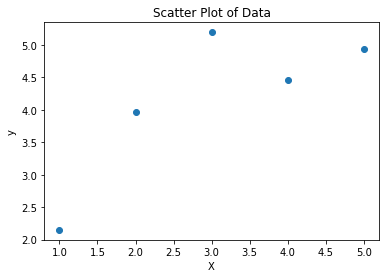

In [2]:

# Example data
np.random.seed(42)
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 5, 4, 5]) + np.random.normal(0, 0.3, size=5)

# Scatter plot
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter Plot of Data")
plt.show()


In [6]:
import numpy as np
import pandas as pd

# Your data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2, 4, 5, 4, 5]) + np.random.normal(0, 0.3, size=5)

# 1. Flatten X because it's currently a 2D column vector
# 2. Create the DataFrame
df = pd.DataFrame({
    'X_Value': X.flatten(),
    'y_Value': y
})

# Only works in Jupyter/Google Colab
df.style.set_table_styles([{'selector': 'table, th, td', 'props': [('border', '1px solid black')]}])

df

,X_Value,y_Value
0,1,2.439695
1,2,3.932267
2,3,5.020258
3,4,3.572576
4,5,4.836685



### Fit Linear Regression Model


In [7]:

model = LinearRegression()
model.fit(X, y)

beta_0 = model.intercept_
beta_1 = model.coef_[0]

beta_0, beta_1


(2.630009324278894, 0.44342895382138825)


The fitted equation is:


$\hat{y} = \beta_0 + \beta_1 x$

where:
- $\beta_0 =$ intercept
- $\beta_1 =$ slope


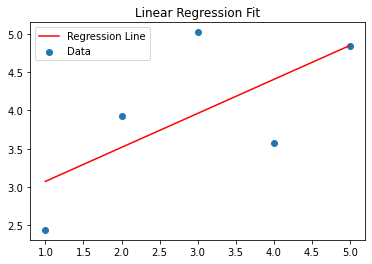

In [8]:

# Plot regression line
X_line = np.linspace(1, 5, 100).reshape(-1, 1)
y_pred = model.predict(X_line)

plt.scatter(X, y, label="Data")
plt.plot(X_line, y_pred, color="red", label="Regression Line")
plt.legend()
plt.title("Linear Regression Fit")
plt.show()



## 2. Manual (Tuned) Regression Line

Suppose we guess:


$\hat{y} = b_0 + b_1 x$

We manually adjust $b_0$ and $b_1$ and visually inspect the fit.


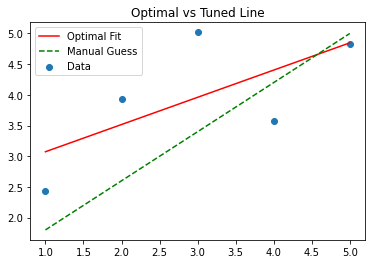

In [9]:

# Manual parameters
b0 = 1.0
b1 = 0.8

y_manual = b0 + b1 * X_line

plt.scatter(X, y, label="Data")
plt.plot(X_line, y_pred, color="red", label="Optimal Fit")
plt.plot(X_line, y_manual, color="green", linestyle="--", label="Manual Guess")
plt.legend()
plt.title("Optimal vs Tuned Line")
plt.show()



## 3. When to Use Linear Regression

Use linear regression when:
- The target variable is continuous
- The relationship between features and target is approximately linear
- Errors are normally distributed and homoscedastic

Examples:
- Predicting house prices
- Predicting temperature
- Predicting sales revenue



## 4. Logistic Regression

Logistic regression is used for **classification**, especially binary outcomes.

### Model Equation


$z = \beta_0 + \beta_1 x $


$\hat{p} = \sigma(z) = \frac{1}{1 + e^{-z}}$

Where:
- $\hat{p}$ = predicted probability of class 1
- $\beta_0$, $\beta_1$ = parameters
- $\sigma(\cdot)$ = sigmoid function

Classification rule:
$
\hat{y} =
\begin{cases}
1 & \text{if } \hat{p} \ge 0.5 \\
0 & \text{otherwise}
\end{cases}
$



### Example Logistic Regression Data

We simulate exam scores and whether a student passed (1) or failed (0).


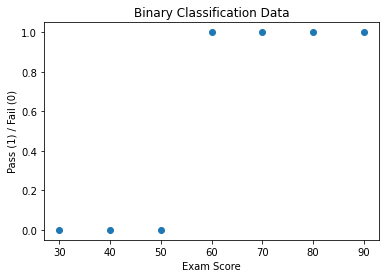

In [10]:

from sklearn.linear_model import LogisticRegression

# Example data
X_log = np.array([30, 40, 50, 60, 70, 80, 90]).reshape(-1, 1)
y_log = np.array([0, 0, 0, 1, 1, 1, 1])

plt.scatter(X_log, y_log)
plt.xlabel("Exam Score")
plt.ylabel("Pass (1) / Fail (0)")
plt.title("Binary Classification Data")
plt.show()


In [12]:
import numpy as np
import pandas as pd
from tabulate import tabulate

# Your data
X_log = np.array([30, 40, 50, 60, 70, 80, 90]).reshape(-1, 1)
y_log = np.array([0, 0, 0, 1, 1, 1, 1])

# Create the DataFrame
df = pd.DataFrame({
    'X_Value': X_log.flatten(),
    'y_Value': y_log
})

# --- CONVERSION LOGIC ---
# This maps 0 to 'fail' and 1 to 'pass'
df['y_Value'] = df['y_Value'].map({0: 'Fail', 1: 'Pass'})

# Display with borders
print(tabulate(df, headers='keys', tablefmt='grid', showindex=False))

+-----------+-----------+
|   X_Value | y_Value   |
+===========+===========+
|        30 | Fail      |
+-----------+-----------+
|        40 | Fail      |
+-----------+-----------+
|        50 | Fail      |
+-----------+-----------+
|        60 | Pass      |
+-----------+-----------+
|        70 | Pass      |
+-----------+-----------+
|        80 | Pass      |
+-----------+-----------+
|        90 | Pass      |
+-----------+-----------+



### Fit Logistic Regression Model


In [13]:

log_model = LogisticRegression()
log_model.fit(X_log, y_log)

beta_0_log = log_model.intercept_[0]
beta_1_log = log_model.coef_[0][0]

beta_0_log, beta_1_log


(-31.09196511750467, 0.5653087296806999)


The logistic regression equation is:


$\hat{p}(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}$


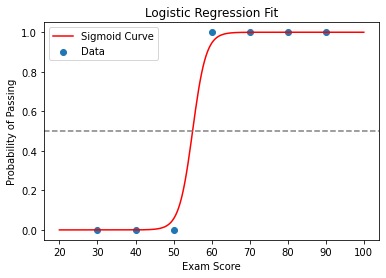

In [14]:

# Plot sigmoid curve
X_curve = np.linspace(20, 100, 200).reshape(-1, 1)
z = beta_0_log + beta_1_log * X_curve
p = 1 / (1 + np.exp(-z))

plt.scatter(X_log, y_log, label="Data")
plt.plot(X_curve, p, color="red", label="Sigmoid Curve")
plt.axhline(0.5, linestyle="--", color="gray")
plt.xlabel("Exam Score")
plt.ylabel("Probability of Passing")
plt.legend()
plt.title("Logistic Regression Fit")
plt.show()



## 5. When to Use Logistic Regression

Use logistic regression when:
- The target variable is categorical (usually binary)
- You want class probabilities
- The relationship between features and log-odds of the outcome is linear

Examples:
- Email spam detection
- Disease diagnosis (yes/no)
- Customer churn prediction



## Summary

| Task | Model |
|------|-------|
| Predict continuous value | Linear Regression |
| Predict class or probability | Logistic Regression |

You have now seen:
- Data visualization
- Model fitting
- Equation interpretation
- Manual tuning
- Proper use cases
